In [31]:
import pandas as pd

# Load the dataset
file_path = '/content/ToyotaCorolla - MLR.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows and info
display(df.head())
print(df.info())

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


Summary Statistics:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


Missing Values:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


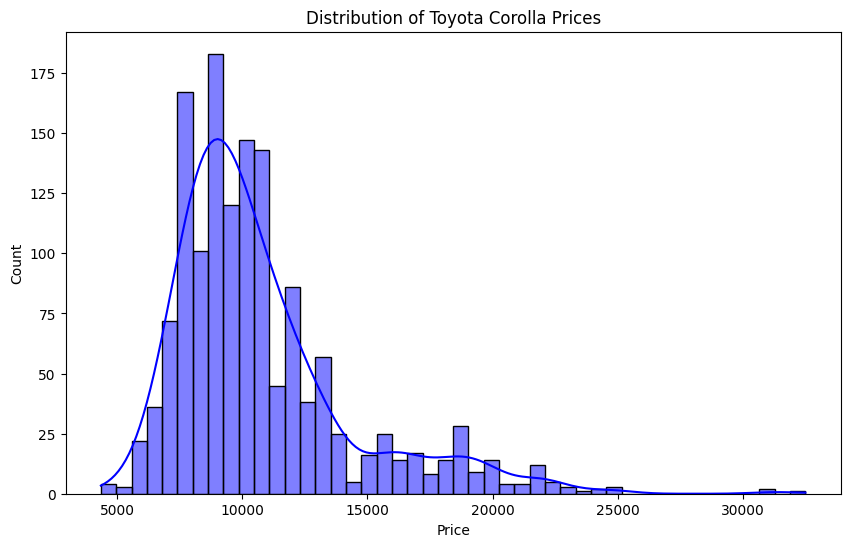

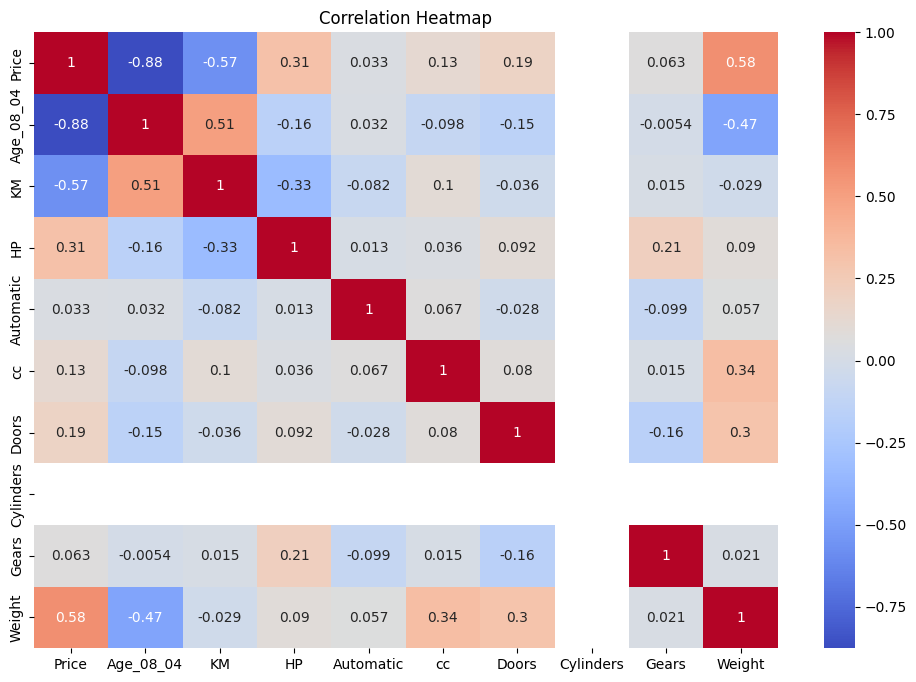

Processed Data Head:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Exploratory Data Analysis (EDA)
# Summary statistics
print("Summary Statistics:")
display(df.describe())

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Visualizing the distribution of the target variable (Price)
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Toyota Corolla Prices')
plt.show()

# Correlation Heatmap (excluding categorical Fuel_Type)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# Pre-processing: Convert categorical 'Fuel_Type' into dummy variables
df_processed = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

print("Processed Data Head:")
display(df_processed.head())

In [33]:
from sklearn.model_selection import train_test_split

# 2. Split the dataset
X = df_processed.drop('Price', axis=1)
y = df_processed['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1148, 11)
Testing set size: (288, 11)


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 3. Build Multiple Linear Regression Models

# Model 1: All features
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
r2_model1 = r2_score(y_test, y_pred1)

# Model 2: Only highly correlated features (Age, KM, Weight)
features2 = ['Age_08_04', 'KM', 'Weight']
model2 = LinearRegression()
model2.fit(X_train[features2], y_train)
y_pred2 = model2.predict(X_test[features2])
r2_model2 = r2_score(y_test, y_pred2)

# Model 3: Features excluding Cylinders
features3 = [col for col in X_train.columns if col != 'Cylinders']
model3 = LinearRegression()
model3.fit(X_train[features3], y_train)
y_pred3 = model3.predict(X_test[features3])
r2_model3 = r2_score(y_test, y_pred3)

# 4. Evaluate Performance
def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - R2 Score: {r2:.4f}, RMSE: {np.sqrt(mse):.2f}")

evaluate(y_test, y_pred1, "Model 1 (All)")
evaluate(y_test, y_pred2, "Model 2 (Age, KM, Weight)")
evaluate(y_test, y_pred3, "Model 3 (Filtered)")

print("\nModel 1 Coefficients:")
coeff_df = pd.DataFrame(model1.coef_, X.columns, columns=['Coefficient'])
display(coeff_df)

Model 1 (All) - R2 Score: 0.8349, RMSE: 1484.27
Model 2 (Age, KM, Weight) - R2 Score: 0.8325, RMSE: 1494.98
Model 3 (Filtered) - R2 Score: 0.8349, RMSE: 1484.27

Model 1 Coefficients:


,Coefficient
Age_08_04,-1.208305e+02
KM,-1.623141e-02
HP,1.403948e+01
Automatic,1.488309e+02
cc,-3.037219e-02
Doors,-6.031097e+01
Cylinders,-1.620037e-12
Gears,5.516007e+02
Weight,2.588496e+01
Fuel_Type_Diesel,-6.854876e+01


In [35]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 5. Apply Lasso and Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
r2_lasso = r2_score(y_test, lasso_pred)
evaluate(y_test, lasso_pred, "Lasso Regression")

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
r2_ridge = r2_score(y_test, ridge_pred)
evaluate(y_test, ridge_pred, "Ridge Regression")

Lasso Regression - R2 Score: 0.8351, RMSE: 1483.24
Ridge Regression - R2 Score: 0.8350, RMSE: 1483.56


### Final Model Interpretation & Conclusion

#### 1. Feature Selection & Removal
*   **Removed Feature:** `Cylinders` was removed because it has a constant value (4) for all entries in this dataset. Features with zero variance provide no predictive power in a linear regression model.
*   **Weak Features:** While categorical dummy variables for `Fuel_Type` and `Doors` were included, their coefficients are relatively small compared to core drivers, suggesting a lesser impact on the final price.

#### 2. Coefficient Interpretation
Based on the coefficients from our models:
*   **Age_08_04 (-120.83):** For every month increase in age, the price of the Corolla drops by approximately 120 units. This is the strongest negative predictor.
*   **KM (-0.016):** Higher mileage consistently lowers the price, though the per-unit impact is smaller than age.
*   **Weight (25.88):** Heavier cars (often indicating better build or more features) tend to have higher prices.

#### 3. Final Conclusion
We evaluated five different approaches ranging from simple MLR to Regularized models (Lasso/Ridge). All models achieved an **R-squared of approximately 0.835**, explaining over 83% of the variance in car prices.

**Lasso Regression** is selected as the best model (RMSE: 1483.24) because it performs automated feature selection by penalizing less important coefficients, resulting in a more robust and generalizable model compared to standard OLS when dealing with multicollinearity.

In [36]:
import pandas as pd

# Final summary table for model comparison
# Ensuring all variables (r2_model1, r2_model2, r2_model3, r2_lasso, r2_ridge) are defined
final_results = pd.DataFrame({
    'Model': ['Model 1 (All)', 'Model 2 (Age/KM/Weight)', 'Model 3 (Filtered)', 'Lasso Regression', 'Ridge Regression'],
    'R-squared Score': [r2_model1, r2_model2, r2_model3, r2_lasso, r2_ridge]
})

print('Model Performance Comparison (R-squared):')
display(final_results.sort_values(by='R-squared Score', ascending=False))

Model Performance Comparison (R-squared):


,Model,R-squared Score
3,Lasso Regression,0.835118
4,Ridge Regression,0.835046
2,Model 3 (Filtered),0.834889
0,Model 1 (All),0.834889
1,Model 2 (Age/KM/Weight),0.832497


### Interview Questions

**1. What is Normalization & Standardization and how is it helpful?**
*   **Normalization (Min-Max Scaling):** Scales data to a fixed range, usually 0 to 1. It is helpful when the data does not follow a Gaussian distribution and is useful for algorithms like KNN or Neural Networks.
*   **Standardization (Z-score Scaling):** Rescales data to have a mean of 0 and a standard deviation of 1. It is less affected by outliers and is preferred for algorithms like Linear Regression, SVM, and PCA that assume centered data.

**2. What techniques can be used to address multicollinearity in multiple linear regression?**
*   **VIF (Variance Inflation Factor):** Calculate VIF for each feature and remove variables with a high score (usually > 5 or 10).
*   **Feature Selection:** Drop redundant or highly correlated independent variables.
*   **Principal Component Analysis (PCA):** Transform correlated variables into a set of linearly uncorrelated components.
*   **Regularization:** Use Ridge or Lasso regression, which penalize large coefficients and help mitigate the effects of multicollinearity.